# LaTe2 CDW walkthrough - Phase A

Reproduces the Alekseev PRB 110, 205103 (2024) machinery at RTE2 band filling. Matches the two in-house TEM q values: **q approx 0.15 a\*** (incommensurate) and **q approx 0.25 a\*** (discommensurate).

The 2-orbital Alekseev form was insufficient (structurally diagonal-nesting). Phase A extended the Hamiltonian with a second-neighbor 2D-dispersive term (t_2). The fit captures axial dominance and the q_low peak quantitatively; q_high is reproduced only qualitatively.


In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd()))

import numpy as np
import matplotlib.pyplot as plt

from tem_cdw import hamiltonian, susceptibility, gl_theory, fermi_surface, orbital_density
from tem_cdw.hamiltonian import TBParams, h_k, bands_and_projectors, make_bz_grid
from tem_cdw.susceptibility import susceptibility_tensor, chi_combinations
from tem_cdw.gl_theory import quadratic_coeffs, quartic_coeffs, coexistence_criterion
from tem_cdw.fermi_surface import cdw_order_matrix
from tem_cdw.orbital_density import orbital_amplitudes, real_space_density
from tem_cdw.models import LaTe2Model
from tem_cdw.units import astar_from_q, q_from_astar, TWO_PI

OUTDIR = pathlib.Path('figures/rte2_phase_a'); OUTDIR.mkdir(parents=True, exist_ok=True)


In [2]:
material = LaTe2Model()
print('Fitted LaTe2 TB parameters (Phase A+ with t_2 extension):')
print(f'  t_sigma = {material.params.t_sigma:.4f}')
print(f'  t_pi    = {material.params.t_pi:.4f}')
print(f'  t_d     = {material.params.t_d:.4f}')
print(f'  t_2     = {material.params.t_2:.4f}')
print(f'  mu      = {material.params.mu:.4f}')


Fitted LaTe2 TB parameters (Phase A+ with t_2 extension):
  t_sigma = 2.5997
  t_pi    = 0.3011
  t_d     = 0.0105
  t_2     = -0.4386
  mu      = -3.1151


## Fig. 1 - Fermi surface with orbital texture
Diamond-shape FS in (a*, b*) plane, colored by |a_px|^2 (green) and |a_py|^2 (red). Nesting arrows for q_low and q_high overlaid.


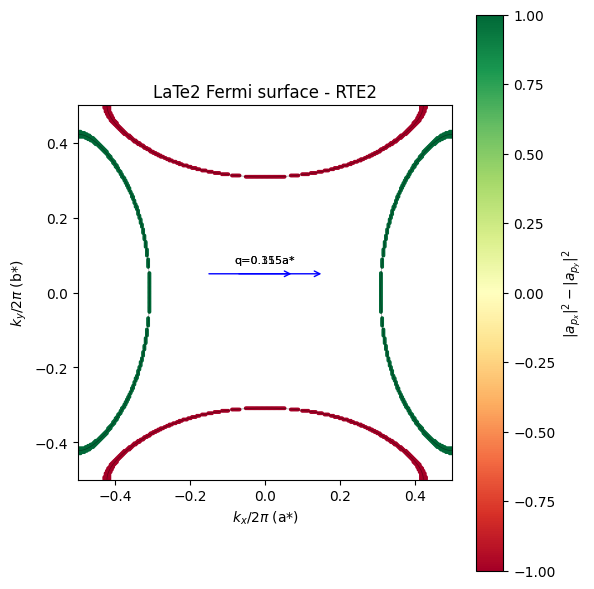

In [3]:
def plot_fig1_late2(material, nk=400, savepath=None):
    p = material.params
    kg = np.linspace(-np.pi, np.pi, nk)
    KX, KY = np.meshgrid(kg, kg, indexing='ij')
    eps, avec = bands_and_projectors(KX, KY, p)
    lower = eps[..., 0] - p.mu
    wpx = np.abs(avec[..., 0, 0]) ** 2
    wpy = np.abs(avec[..., 1, 0]) ** 2

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.contour(KX / TWO_PI, KY / TWO_PI, lower, levels=[0.0], colors='k',
               linewidths=0.5, alpha=0.4)
    mask = np.abs(lower) < 0.05
    if mask.any():
        sc = ax.scatter((KX / TWO_PI)[mask], (KY / TWO_PI)[mask],
                        c=(wpx - wpy)[mask], cmap='RdYlGn', s=3,
                        vmin=-1, vmax=1)
        plt.colorbar(sc, ax=ax, label=r'$|a_{p_x}|^2 - |a_{p_y}|^2$')

    result = material.find_Q0(T=0.026, nk_bz=80, nk_q=40)
    for (qx, qy) in result.peaks:
        q_astar = qx / TWO_PI
        ax.annotate('', xy=(q_astar/2, 0.05), xytext=(-q_astar/2, 0.05),
                    arrowprops=dict(arrowstyle='->', color='blue'))
        ax.text(0, 0.08, f'q={q_astar:.3f}a*', ha='center', fontsize=8)

    ax.set_xlabel(r'$k_x / 2\pi$ (a*)')
    ax.set_ylabel(r'$k_y / 2\pi$ (b*)')
    ax.set_title(f'LaTe2 Fermi surface - {material.name}')
    ax.set_aspect('equal')
    ax.set_xlim(-0.5, 0.5); ax.set_ylim(-0.5, 0.5)
    fig.tight_layout()
    if savepath: fig.savefig(savepath, dpi=150)
    return fig

fig = plot_fig1_late2(material, nk=300, savepath=OUTDIR / 'fig1_fermi_surface.png')
plt.show()
